# Task 2: Multi-Object Tracking
In this task, the goal is to combine measurements from a camera and LIDAR sensors in order to track vehicles that are around ours.

The steps to do this include:
* Reading the data
* Calculating a Bird's Eye View perspective from the point cloud data of LIDAR
* Running a 3D object detection model on this view to find possible vehicles to track.

## Format


### Frame:

- **id** *(string)*: A unique identifier for the frame
- **cameras** *(list of Camera Object)*: contains data from multiple cameras
- **lidars** *(list of Lidar Object)*: contains data from multiple lidars

### Camera:

- **data** *(bytes fiel)*: the raw image data from the camera
- **width** *(int32 field)*: the width of the image in pixels
- **height** *(int32 field)*: the height of the image in pixels
- **depth** *(int32 field)*: the number of channels in the image (e.g. 3 for RGB)
- **T** *(list of float field)*: a list of transformation values that specify the camera's position and orientation in space, relative to the vehicle, presented as a flattened vector. The transformation matrix is traditionally given as follows:

    $$
    \mathbf{T} = 
    \begin{bmatrix}
    R_{00} & R_{01} & R_{02} & t_x\\
    R_{10} & R_{11} & R_{12} & t_y\\
    R_{20} & R_{21} & R_{22} & t_z\\
    0 & 0 & 0 & 1\\
    \end{bmatrix}
    $$

    In this matrix, $R_{ij}$ elements represent the rotation matrix and $t_x$, $t_y$, $t_z$ denote the translation components along the x, y, and z axes, respectively.

- **K** *(list of float field)*: a list of camera calibration values, provided as a flattened vector. Typically, these parameters are represented in matrix form in the literature, as shown below:

    $$
    \mathbf{K} = 
    \begin{bmatrix}
    f_x & 0 & c_x \\
    0 & f_y & c_y \\
    0 & 0 & 1
    \end{bmatrix}
    $$

    Where $f_x$ and $c_x$ denote the focal length and the principal point coordinates of the camera along the x-axis, respectively. Similarly, $f_y$ and $c_y$ represent the focal length and the principal point coordinates along the y-axis

- **D** *(list of float field)*: a list of the Distortion values of the image.
- **pos** *(Position message field)*: a Position enum value that describes the position of the camera relative to the vehicle
- **detections** *(list of CameraDetection field)*: contains a list of CameraDetection messages, each of which represents an object detection within the camera's view
- **timestamp** (float): contains the timestamp in epochs of the time when the image was recorded.

### CameraDetection:

- **id** *(string field)*: a unique identifier for the detected object
- **type** *(ObjectType field)*: an ObjectType enum value that indicates the type of object detected
- **bbox** *(list of float field)*: a list of four floating-point values that define the bounding box coordinates for a detected object within the image. These values represent the center coordinates (x0, y0) and the dimensions (width, height) of the bounding box in the image.

### Lidar:

- **data** *(list of float field)*: a list of raw lidar data points
- **width** *(int32 field)*: the number of horizontal points in the lidar scan
- **height** *(int32 field)*: the number of vertical points in the lidar scan
- **channels** *(int32 field)*: the number of channels in each lidar point (e.g. 3 for x, y, z coordinates)
- **T** *(list of float field)*: a list of transformation values that specify the lidar's position and orientation in space, relative to the vehicle, presented as a flattened vector. The transformation matrix is traditionally given as follows:

    $$
    \mathbf{T} = 
    \begin{bmatrix}
    R_{00} & R_{01} & R_{02} & t_x\\
    R_{10} & R_{11} & R_{12} & t_y\\
    R_{20} & R_{21} & R_{22} & t_z\\
    0 & 0 & 0 & 1\\
    \end{bmatrix}
    $$
    
    In this matrix, $R_{ij}$ elements represent the rotation matrix and $t_x$, $t_y$, $t_z$ denote the translation components along the x, y, and z axes, respectively.

- **pos** *(Position message field)*: a Position enum value that describes the position of the lidar relative to the vehicle
- **detections** *(list of LidarDetection field)*: contains a list of LidarDetection messages, each of which represents an object detection within the lidar's range
- **timestamp** (float): contains the timestamp in epochs of the time when the image was recorded.

### LidarDetection:

- **id** *(string field)*: a unique identifier for the detected object
- **type** *(ObjectType enum field)*: an ObjectType enum value that indicates the type of object detected
- **pos** *(repeated float field)*: a list of three float values that represent the x, y, and z coordinates of the center of the detected object in 3D space
- **rot** *(repeated float field)*: a list of three float values that represent the roll, pitch, and yaw angles of the detected object in 3D space
- **scale** *(repeated float field)*: a list of three float values that represent the x, y, and z scale of the detected object in 3D space

## Python Usage

### General imports

In [1]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch

print(torch.cuda.is_available())

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
True


### Decoding a frame

#### Read a frame

For convinience we have developed a custom function within our <code>dataset_tools</code> script. This function simplifies the process of accessing and manipulating the data. You just need to provided the path to the frame in the protobuf format.  It reads and deserializes the data from the specified file into a Frame object, which conforms to our predefined schema. The Frame object encapsulates, including unique identifiers, and detailed sensor outputs such as camera images and lidar point clouds, each embedded with metadata like dimensions, transformations, and detection information.

In [2]:
frame = dataset_tools.read_frame("./Dataset/data_2/frame_0.pb")

#### Camera data

The camera data in each frame is encapsulated within a <code>Camera</code> object, which provides details about the camera that captured the image as well as the image itself. Each <code>Frame</code> has a list of <code>Camera</code> objecst that can be accessed by indexing. For this example we are only decoding The center camera of the vehicle. 

##### Extract Camera and Parameters

In [3]:
# Extract the camera object from the Frame
camera = frame.cameras[0]

print(f"Timestamp: {camera.timestamp}")
print(f"Image width: {camera.width}")
print(f"Image height: {camera.height}")
print(f"Image channels: {camera.depth}")

# Extract intrinsic parameters obtained from calibration
camera_intrinsic_mtx = np.asarray(camera.K).reshape(3,3)
# Extract distortion from calibration
camera_distortion = np.asarray(camera.D)
# Extract extrinsic parameters obtined from calibration
veh_to_camera_mtx = np.asarray(camera.T).reshape(4,4)

print("Vehicle to Camera Transformation:")
display(Matrix(veh_to_camera_mtx))
print("Camera intrinsic parameters")
display(Matrix(camera_intrinsic_mtx))
print("Camera distortion")
display(Matrix(camera_distortion))

Timestamp: 1510593600.1401389
Image width: 1280
Image height: 1920
Image channels: 3
Vehicle to Camera Transformation:


Matrix([
[0.00828052964061499,   -0.999915063381195,  0.0100662931799889, -0.0569637827575207],
[  0.010053132660687, -0.00998288579285145,  -0.999899625778198,    2.09998655319214],
[  0.999915182590485,  0.00838089641183615, 0.00996961444616318,   -1.56518697738647],
[                0.0,                  0.0,                 0.0,                 1.0]])

Camera intrinsic parameters


Matrix([
[2083.09130859375,              0.0, 957.293823242188],
[             0.0, 2083.09130859375, 650.569763183594],
[             0.0,              0.0,              1.0]])

Camera distortion


Matrix([
[0.0],
[0.0],
[0.0],
[0.0],
[0.0]])

##### Extract image

After exploring the structure and attributes of the camera, let's proceed to decode an image from our dataset. For this purpose, we utilize a function from <code>dataset_tools</code> named <code>decode_img</code>. This function decodes the raw image data from the camera and returns it as a <code>numpy</code> array of shape (<code>camera.width</code>, <code>camera.height</code>, <code>camera.depth</code>).

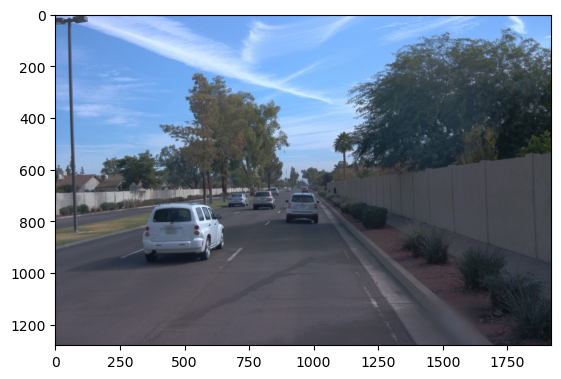

In [4]:
# Decode the image
img_array = dataset_tools.decode_img(camera)
# Plot the image using matplotlib
plt.figure()
plt.imshow(img_array)


##### Extract and plot detections

The <code>Camera</code> object contains a list of <code>CameraDetections</code>, which holds all the detections made by the camera. Each <code>CameraDetection</code> entry provides key details, including the type of object detected, the coordinates of its bounding box, and additional relevant metadata. Let's visualize these detections by plotting them on the image.

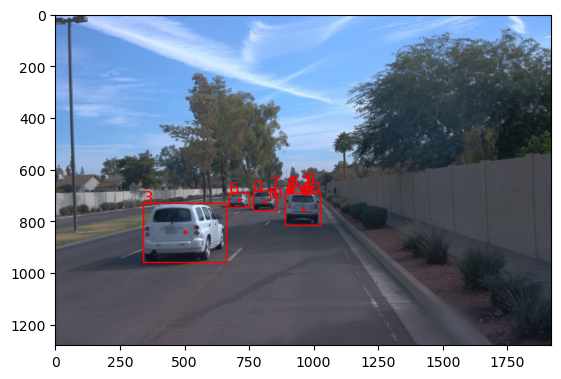

In [5]:
# Defining Color Labels for Detections

LABEL_COLOR_DICT = {
    0: (1.0, 0, 0), # Car red
    1: (0, 1.0, 0), # Truck green
    2: (0, 0, 1.0), # Pedestrian blue
    3: (0, 0.5, 0.5) # Cyclist
}

# Retrieve the list of detections from the camera object
camera_detections = camera.detections

# Show image
fig, ax = plt.subplots()
ax.imshow(img_array)

# Dictionary to transform from cameras ids to numeric ids 
ids_to_num = {}
i = 0

# We iterate through each detection
for detection in camera_detections:
    
    # Extract bbox parameters and
    # calculate the up-left corner
    x0, y0, width, height = detection.bbox
    x1 = x0 - height/2
    y1 = y0 - width/2

    # Assign a numeric id to the detection
    if ids_to_num.get(detection.id) is None:
        ids_to_num[detection.id] = i
        i += 1
    id = ids_to_num[detection.id]
    
    # Extract label and assign a color
    label = detection.type
    color = LABEL_COLOR_DICT[label]

    # Plot detection.
    r = patches.Rectangle((x1,y1),height, width, linewidth=1, edgecolor='r', facecolor='none')
    ax.scatter(x0, y0, color=color, s=3)
    ax.add_patch(r)
    ax.text(x1, y1, str(id), color=color, fontsize=12)
    
plt.show()


#### Lidar Data

##### Extract Lidar and Lidar Parameters

Similar than with the camera, the LIDAR data in each frame is encapsulated within a <code>Lidar</code> object, which provides details about the LIDAR that captured the pointcloud as well as the pointcloud itself. Each <code>Frame</code> has a list of <code>Lidar</code> objects that can be accessed by indexing. For this example we are only decoding The center Lidar of the vehicle. 

In [6]:
lidar = frame.lidars[0]

print(f"Timestamp: {lidar.timestamp}")
print(f"No of layers: {lidar.height}")
print(f"Points per layer: {lidar.width}")
print(f"No of channels: {lidar.channels}")

veh_to_lidar_mtx = np.asarray(lidar.T).reshape(4,4)

print("Vehicle to Lidar Transformation:")
display(Matrix(veh_to_lidar_mtx))


Timestamp: 1510593600.1401389
No of layers: 64
Points per layer: 3072
No of channels: 4
Vehicle to Lidar Transformation:


Matrix([
[  -0.852671921253204,    0.522445142269135, -0.00128078227862716,  1.22211813926697],
[  -0.522437870502472,   -0.852669239044189, -0.00372029235586524, 0.755211293697357],
[-0.00303573231212795, -0.00250305980443954,    0.999992251396179, -2.17964196205139],
[                 0.0,                  0.0,                  0.0,               1.0]])

##### decode pointcloud data

After exploring the structure and attributes of the lidar, let's proceed to decode the pointcloud from the Lidar. For this purpose, we utilize a function from <code>dataset_tools</code> named <code>decode_lidar</code>. This function decodes the pointcloud data from the lidar and returns it as a <code>numpy</code> array of shape (<code>lidar.width*lidar.height</code>,<code>lidar.channels</code>).

In [7]:
# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Pointcloud shape: (196608, 4)


In [8]:

def pcl_to_bev(pcl:np.ndarray, configs: edict) -> np.ndarray:
    """Computes the bev map of a given pointcloud. 
    
    For generality, this method can return the bev map of the available 
    channels listed in '''BEVConfig.VALID_CHANNELS'''. 

    Parameters
    ----------
        pcl (np.ndarray): pointcloud as a numpy array of shape [n_points, m_channles] 
        configs (Dict): configuration parameters of the resulting bev_map

    Returns
    -------
        bev_map (np.ndarray): bev_map as numpy array of shape [len(config.channels), configs.bev_height, configs.bev_width ]
    """
    pcl = pcl.copy()
    # Step 1:
    # remove lidar points outside detection area
    mask = np.where((pcl[:, 0] >= configs.lims.x[0]) & (pcl[:, 0] <= configs.lims.x[1]) &
                    (pcl[:, 1] >= configs.lims.y[0]) & (pcl[:, 1] <= configs.lims.y[1]) &
                    (pcl[:, 2] >= configs.lims.z[0]) & (pcl[:, 2] <= configs.lims.z[1]))
    pcl = pcl[mask]
    # shift level of ground plane to avoid flipping from 0 to 255 for neighboring pixels
    pcl[:, 2] = pcl[:, 2] - configs.lims.z[0]
    # limit intensity values
    pcl[pcl[:,3]<configs.lims.intensity[0],3] = configs.lims.intensity[0]
    pcl[pcl[:,3]>configs.lims.intensity[1],3] = configs.lims.intensity[1]  

    # Step 2:
    # Convert sensor coordinates to bev-map coordinates (center is bottom-middle)
    # compute bev-map discretization by dividing x-range by the bev-image height
    bev_x_discret = (configs.lims.x[1] - configs.lims.x[0]) / configs.bev_height
    bev_y_discret = (configs.lims.y[1] - configs.lims.y[0]) / configs.bev_width
    
    # Step 3:
    ## transform all metrix x-coordinates into bev-image coordinates    
    pcl[:, 0] = np.int_(np.floor(pcl[:, 0] / bev_x_discret))
    # transform all y-coordinates making sure that no negative bev-coordinates occur
    pcl[:, 1] = np.int_(np.floor(pcl[:, 1] / bev_y_discret) + (configs.bev_width + 1) / 2) 
    
    # Step 4:
    # Sort poitncloud by x, y, and then z
    pcl_height_sorted, counts = sort_and_map(pcl, 2, return_counts=True)
    xs = np.int_(pcl_height_sorted[:, 0])
    ys = np.int_(pcl_height_sorted[:, 1])
    
    # Step 5:
    # Compute height channel
    normalized_height = pcl_height_sorted[:, 2]/float(np.abs(configs.lims.z[1] - configs.lims.z[0]))
    # Fill height map
    height_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    height_map[xs,ys] = normalized_height
    
    # Step 6:
    # Compute density channel
    normalized_density = np.minimum(1.0, np.log(counts + 1) / np.log(64))
    # Fill density map
    density_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    density_map[xs,ys] = normalized_density

    # Step 7:
    # Filter intensities that are bi    
    pcl_int_sorted, _ = sort_and_map(pcl, 3, return_counts=False)
    xs = np.int_(pcl_int_sorted[:, 0])
    ys = np.int_(pcl_int_sorted[:, 1])
    
    normalized_int = pcl_int_sorted[:, 3]/(np.amax(pcl_int_sorted[:, 3])-np.amin(pcl_int_sorted[:, 3]))

    intensity_map = np.zeros((configs.bev_height + 1, configs.bev_width + 1))
    intensity_map[xs,ys] = normalized_int

    # Step 8:    
    # Create BEV map
    bev_map = np.zeros((3, configs.bev_height, configs.bev_width))
    # Fill BEV 
    bev_map[2,:,:] = density_map[:configs.bev_height, :configs.bev_width]
    bev_map[1,:,:] = height_map[:configs.bev_height, :configs.bev_width]
    bev_map[0,:,:] = intensity_map[:configs.bev_height, :configs.bev_width]
 
    return bev_map

def sort_and_map(pcl: np.ndarray, channel_index: int, return_counts:bool=False) ->Tuple[np.ndarray,np.ndarray]:
    """Function to re-arrange elements in poincloud by sorting first by x, then y, then -channel.
    This function allows users to map a pointcloud channel to a top view image (in z axis) of that channel.

    Parameters
    ----------
        pcl (np.ndarray): Input pointcloud of of shape [n_points, m_channles]
        channel_index (int): Index of channel to take into account as third factor, 
                             when sorting the pointcloud.
        return_counts (bool): True to return the counts on points per cell. Used for density channel
    Returns
     ----------
       pcl_sorted (np.ndarray): Sorted poincloud by $x$, then $y$, then $-channel$. This function return only
                                one point per unique pair ($x$,$y$) with the maximum value in the $channel$ 
                                coordinate.
       counts (np.ndarray): Return the amount of points per unique pair ($x$,$y$) if return counts is true
                            or None otherwise.
       
    """

    idx= np.lexsort((-pcl[:, channel_index], pcl[:, 1], pcl[:, 0]))
    pcl_sorted = pcl[idx]
    counts = None
    # extract all points with identical x and y such that only the maximum value of the channel is kept
    if return_counts:
        _, indices, counts = np.unique(pcl_sorted[:, 0:2], axis=0, return_index=True, return_counts=return_counts)
    else:
        _, indices = np.unique(pcl_sorted[:, 0:2], axis=0, return_index=True)
    return (pcl_sorted[indices], counts)


configs = edict()
configs.lims = edict()
configs.lims.x = [0, 50]
configs.lims.y = [-25, 25]
configs.lims.z = [-1, 3]
configs.lims.intensity = [0, 1]
configs.bev_height = 608
configs.bev_width = 608

In [9]:
bev_map = pcl_to_bev(pcl, configs)
bev_map.shape

(3, 608, 608)

In [10]:
from SFA3D.sfa.models.model_utils import create_model

configs = edict({
    "saved_fn": "fpn_resnet_18",
    "arch": "fpn_resnet_18",
    "pretrained_path": "./SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth",
    "K": 50,
    "no_cuda": False,
    "gpu_idx": 0,
    "num_samples": None,
    "num_workers": 1,
    "batch_size": 1,
    "peak_thresh": 0.2,
    "save_test_output": False,
    "output_format": "image",
    "output_video_fn": "out_fpn_resnet_18",
    "output_width": 608,
})
configs.pin_memory = True
configs.distributed = False  # For testing on 1 GPU only

configs.input_size = (608, 608)
configs.hm_size = (152, 152)
configs.down_ratio = 4
configs.max_objects = 50

configs.imagenet_pretrained = False
configs.head_conv = 64
configs.num_classes = 3
configs.num_center_offset = 2
configs.num_z = 1
configs.num_dim = 3
configs.num_direction = 2  # sin, cos

configs.heads = {
    'hm_cen': configs.num_classes,
    'cen_offset': configs.num_center_offset,
    'direction': configs.num_direction,
    'z_coor': configs.num_z,
    'dim': configs.num_dim
}
configs.num_input_features = 4

model = create_model(configs)
model.load_state_dict(torch.load(configs.pretrained_path, map_location='cuda'))
model = model.to("cuda:0")
model.eval()


using ResNet architecture with feature pyramid


PoseResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True

In [11]:
inputs_bevs = torch.from_numpy(bev_map).unsqueeze(0).to("cuda:0").float()
model(inputs_bevs)

{'hm_cen': tensor([[[[-15.9140, -19.4236, -20.2383,  ..., -13.5611, -13.7791, -10.6133],
           [-22.5217, -26.7613, -27.1284,  ..., -19.8564, -20.0546, -14.5976],
           [-24.3489, -29.1279, -29.3141,  ..., -19.5157, -19.6756, -14.7133],
           ...,
           [-13.6843, -17.1948, -16.9940,  ..., -11.3136, -11.3286,  -7.9979],
           [-13.0599, -16.3954, -16.2256,  ..., -11.4685, -12.0401,  -9.2398],
           [ -8.7173, -11.3781, -11.2114,  ...,  -9.0557,  -9.0782,  -7.1058]],
 
          [[ -6.6977,  -9.2855, -10.0692,  ...,  -7.8786,  -7.5435,  -5.9209],
           [-10.7933, -14.0723, -14.9667,  ...,  -9.9090,  -9.4483,  -7.4080],
           [-13.3262, -16.6756, -17.5684,  ..., -10.0427,  -9.6842,  -7.5714],
           ...,
           [ -6.3673,  -7.4911,  -7.8391,  ...,  -7.8188,  -7.5818,  -5.9253],
           [ -5.9636,  -7.1225,  -7.4493,  ...,  -7.9749,  -7.9088,  -6.7724],
           [ -5.1607,  -5.6873,  -5.9509,  ...,  -6.6785,  -6.4985,  -5.7635]],
 
    

##### Extract and plot detections on pointcloud

The <code>Lidar</code> object contains a list of <code>LidarDetections</code>, which holds all the detections made by the camera. Each <code>LidarDetection</code> entry provides key details, including the type of object detected, the coordinates of the center of its bounding box, the rotation of the bounding box and the size. Let's visualize these detections by plotting them on a pointcloud.

In [13]:
def show_pcl(pcl, bboxes):
    """
    Visualize point cloud data with 3D bounding boxes
    
    Parameters:
    -----------
    pcl : numpy.ndarray
        Point cloud data with shape (n_points, channels)
    bboxes : list
        List of bounding boxes, where each box is [center, rotation_matrix, size, id]
    """
    # Create Open3D point cloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pcl[:, :3])  # Use only XYZ coordinates
    
    # Set point cloud color (optional - white by default)
    # You can use pcl[:, 3] for intensity if available
    pcd.colors = o3d.utility.Vector3dVector(np.ones((len(pcl), 3)) * 0.7)  # Light gray
    
    # Create visualization objects
    vis_objects = [pcd]
    
    # Add bounding boxes
    for box in bboxes:
        center, rotation_matrix, box_size, box_id = box
        
        # Create oriented bounding box
        obb = o3d.geometry.OrientedBoundingBox(
            center=center,
            R=rotation_matrix,
            extent=box_size
        )
        
        # Set color based on ID (cycle through colors)
        colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1]]
        color = colors[box_id % len(colors)]
        obb.color = color
        
        # Add to visualization
        vis_objects.append(obb)
        
        # Add text label for ID (Open3D doesn't support text, so we'll skip this)
        # For actual labeling, you would need to implement this differently
    
    # Visualize
    o3d.visualization.draw_geometries(vis_objects,
                                     window_name="Point Cloud with Bounding Boxes",
                                     width=1024, height=768)
    
    return vis_objects

In [14]:
# Extract lidar detections
detections = lidar.detections

# Placeholder to store the boxes
bboxes = []
ids = []
for detection in lidar.detections:
    # Extract bbox center (x,y,z )
    bbox_center = np.array(detection.pos)
    # Extract bbox orientation (roll, pitch, yaw)
    bbox_rot = np.array(detection.rot)
    # Extract bbox size (x, y, z)
    bbox_size = np.array(detection.scale)
    label = detection.type
    # Get color for bounding box
    color = LABEL_COLOR_DICT[label]
    
    # Convert IDs to numbers    
    if ids_to_num.get(detection.id) is None:
        ids_to_num[detection.id] = i
        i+=1

    id = ids_to_num[detection.id]

    # Convert Detection orientation from Euler angles to matrix   
    R = Rotation.from_euler('xyz', bbox_rot).as_matrix()

    # Append boxes
    bboxes.append([bbox_center, R, bbox_size, id])

# Plot boxes the core of plotting them relies on the function
# o3d.geometry.OrientedBoundingBox(bbox_center, bbox_rot, bbox_size)

show_pcl(pcl, bboxes) # comment if you dont have a running visualization
                      # inside docker you have to care that you are forwarding the xserver.

[PointCloud with 196608 points.,
 OrientedBoundingBox: center: (-20.02, 7.25577, 0.502489), extent: 4.76024, 1.9829, 1.68),
 OrientedBoundingBox: center: (50.411, 3.75742, 0.963488), extent: 4.51313, 2.01817, 1.77),
 OrientedBoundingBox: center: (17.7356, 3.56386, 0.902286), extent: 4.2737, 1.93845, 1.69),
 OrientedBoundingBox: center: (59.6843, 7.29404, 0.792057), extent: 4.2516, 1.8789, 1.52),
 OrientedBoundingBox: center: (32.7718, 0.192735, 1.0237), extent: 4.30796, 2.03544, 1.91),
 OrientedBoundingBox: center: (-15.9474, 22.7407, -0.197873), extent: 5.7469, 2.32999, 2.05)]

#### Project coordinates to image

In our lesson, we examined the pinhole camera model. As a refresher, consider the following image:

![image_1](https://github.com/leggedrobotics/darknet_ros/assets/27258035/a5300b02-a4e7-4cf4-a89b-c9be3f157567)

Based on this, we can calculate the coordinates of a point  $(p_x, p_y, p_z)$ in image coordinates using the following formula:

$$
x_{img} = c_x - f_x\frac{p_y}{p_x} \\
y_{img} = c_y - f_y\frac{p_z}{p_x}
$$

Here, $f_x$ and $c_x$ denote the focal length and the principal point coordinates of the camera along the x-axis, respectively. Similarly, $f_y$ and $c_y$ represent the focal length and the principal point coordinates along the y-axis

These equations assume that the coordinate system matches the one depicted in the image above. However, in the dataset, transformation matrices convert points to the camera's reference system, as illustrated in the subsequent image:


![image_2](https://github.com/leggedrobotics/darknet_ros/assets/27258035/93220364-3284-4815-9761-a2b161132984)


With this in mind, there has to be a slight modification on the equations above as after transformaiton the depth is the z axis and the x the horizontal axis. Also see that y axis is inverted, therefore the image is:

$$
x_{img} = c_x + f_x \frac{p_x}{p_z} \\ \\
y_{img} = c_y + f_y \frac{p_y}{p_z}
$$

Let's explore how to convert these coordinates using our dataset, aiming to plot the centers of boxes from the LiDAR perspective to the camera perspective.

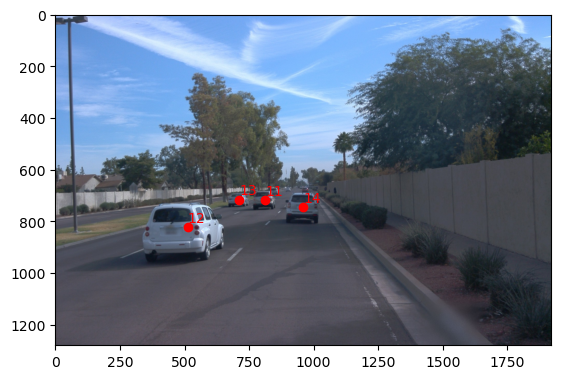

In [15]:
plt.figure()
plt.imshow(img_array)
for box in bboxes:

    box_center = box[0]
    box_rot_mtx = box[1]
    box_size = box[2]
    id = box[3]

    # Filter boxes that are behind the vehicle
    if box_center[0] < 0 or box_center[0] > 100:
        continue

    box_center = np.asarray([box_center])

    # Transform to homogeneous coordinates [x,y,z,1]
    center_3d_homogeneous = np.ones((box_center.shape[0], box_center.shape[1]+1))
    center_3d_homogeneous[:,:3] = box_center
    
    # Transform the from lidar perspective to camera perspective
    transformed_center = (veh_to_camera_mtx@center_3d_homogeneous.T).T
    transformed_center = transformed_center[:,:3]
    
    # Extract depth information
    depth = transformed_center[:,-1:]

    # Scale corners in 3D
    # px' = px/pz, py' = py/pz
    # [px, py, pz] -> [px/pz, py/pz, 1] 
    scaled_corners_3D = transformed_center / depth
    
    # Transform to image perspective
    corners_2D = (camera_intrinsic_mtx@scaled_corners_3D.T).T
    corners_2D[:,-1] = depth
    
    plt.scatter(corners_2D[:,0], corners_2D[:,1], color='r')
    plt.text(corners_2D[:,0], corners_2D[:,1]-20, id,  color='r', fontsize=10)

### Example of using the frame to create tracks

Now let's explify how to initilize the tracks and how to plot them using the lidar data

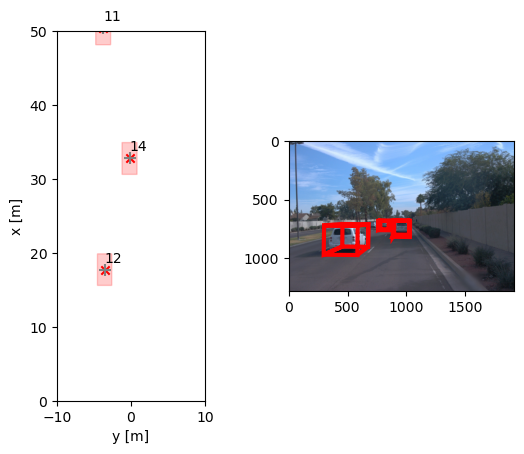

In [16]:
class Track:
    
    def __init__(self, detection):
        self.x = np.asarray(detection.pos)
        self.l = detection.scale[0]
        self.w = detection.scale[1]
        self.h = detection.scale[2]
        self.yaw = detection.rot[2]
        self.state = "initialized"
        # Convert IDs to numbers    
        if ids_to_num.get(detection.id) is None:
            ids_to_num[detection.id] = i
            i+=1

        self.id = ids_to_num[detection.id]

tracks = [Track(detection) for detection in lidar.detections if detection.pos[0]>0 and detection.pos[0]<55]

plot_tools.plot_tracks(img_array,tracks,[], lidar.detections, camera)

In [20]:
import os
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm
import tempfile
import shutil

# Dictionary to map detection IDs to track IDs
ids_to_num = {}
i = 0

# First, let's check what valid states are defined in plot_tools
print("Available track states in COLOR_DICT:", list(plot_tools.COLOR_DICT.keys()))

class Track:
    def __init__(self, detection):
        self.x = np.asarray(detection.pos)
        self.l = detection.scale[0]
        self.w = detection.scale[1]
        self.h = detection.scale[2]
        self.yaw = detection.rot[2]
        # Use a state that's defined in COLOR_DICT
        self.state = "initialized"  # This should be available in COLOR_DICT
        
        # Convert IDs to numbers    
        global ids_to_num, i
        if ids_to_num.get(detection.id) is None:
            ids_to_num[detection.id] = i
            i += 1

        self.id = ids_to_num[detection.id]
        
        # Add attributes for tracking
        self.age = 0
        self.time_since_update = 0
        self.hits = 1
        
    def update(self, detection):
        # Update track with new detection
        self.x = np.asarray(detection.pos)
        self.l = detection.scale[0]
        self.w = detection.scale[1]
        self.h = detection.scale[2]
        self.yaw = detection.rot[2]
        
        # Change the state based on number of hits - use states from COLOR_DICT 
        if self.hits >= 3:
            self.state = "confirmed"  # This should be available in COLOR_DICT
        else:
            self.state = "tentative"  # This should be available in COLOR_DICT
            
        self.time_since_update = 0
        self.hits += 1
        self.age += 1

# Create a temporary directory for frame images
output_dir = "tracking_frames"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Get all frame files in dataset
dataset_path = "./Dataset/data_2/"
frame_files = sorted([f for f in os.listdir(dataset_path) if f.startswith("frame_") and f.endswith(".pb")])

# Parameters for track management
max_age = 5  # Maximum frames to keep a track without updates
min_hits = 3  # Minimum number of detections before track is considered confirmed

# List to store all tracks
all_tracks = []

# Process each frame
for frame_idx, frame_file in enumerate(tqdm(frame_files, desc="Processing frames")):
    # Read frame
    frame = dataset_tools.read_frame(os.path.join(dataset_path, frame_file))
    
    # Get lidar from frame
    lidar = frame.lidars[0]
    
    # Get camera from frame
    camera = frame.cameras[0]
    
    # Filter detections (only consider those in front and within 55 units)
    filtered_detections = [detection for detection in lidar.detections 
                          if detection.pos[0] > 0 and detection.pos[0] < 55]
    
    # If we have existing tracks, associate detections with tracks
    if all_tracks:
        # Create cost matrix for assignment
        cost_matrix = np.zeros((len(all_tracks), len(filtered_detections)))
        
        for t_idx, track in enumerate(all_tracks):
            for d_idx, detection in enumerate(filtered_detections):
                # Calculate distance between track and detection
                det_pos = np.asarray(detection.pos)
                distance = np.linalg.norm(track.x - det_pos)
                cost_matrix[t_idx, d_idx] = distance
        
        # Use Hungarian algorithm for optimal assignment
        if cost_matrix.size > 0 and min(cost_matrix.shape) > 0:  # Check if matrix has valid dimensions
            # Set a maximum acceptable distance
            max_distance = 3.0  # Adjust based on your scenario
            cost_matrix[cost_matrix > max_distance] = 1000000  # Large value for distances beyond threshold
            
            row_indices, col_indices = linear_sum_assignment(cost_matrix)
            
            # Update matched tracks
            matched_detection_indices = set()
            for row_idx, col_idx in zip(row_indices, col_indices):
                if cost_matrix[row_idx, col_idx] < max_distance:
                    all_tracks[row_idx].update(filtered_detections[col_idx])
                    matched_detection_indices.add(col_idx)
            
            # Create new tracks for unmatched detections
            for d_idx, detection in enumerate(filtered_detections):
                if d_idx not in matched_detection_indices:
                    all_tracks.append(Track(detection))
            
            # Increment age of unmatched tracks
            for t_idx, track in enumerate(all_tracks):
                if t_idx not in row_indices or cost_matrix[t_idx, col_indices[list(row_indices).index(t_idx)]] >= max_distance:
                    track.time_since_update += 1
                    track.age += 1
                    # Use "tentative" instead of "lost" since "lost" doesn't exist in COLOR_DICT
                    if track.time_since_update > 2:
                        track.state = "tentative"  # Use an existing state
    else:
        # First frame - create tracks for all detections
        all_tracks = [Track(detection) for detection in filtered_detections]
    
    # Remove old tracks
    all_tracks = [track for track in all_tracks if track.time_since_update <= max_age]
    
    # Get current active tracks (confirmed tracks)
    active_tracks = [track for track in all_tracks if track.hits >= min_hits]
    
    # For visualization: decode image and display with tracks
    img_array = dataset_tools.decode_img(camera)
    
    # Save frame with tracks visualized
    if True:  # Always save frame, even if no active tracks
        try:
            # Create figure for plotting
            plt.figure(figsize=(10, 6))
            
            # Plot tracks on the image
            if active_tracks:
                plot_tools.plot_tracks(img_array, active_tracks, [], lidar.detections, camera)
            else:
                plt.imshow(img_array)
                
            # Save the figure
            frame_path = os.path.join(output_dir, f"frame_{frame_idx:04d}.png")
            plt.savefig(frame_path, bbox_inches='tight', dpi=150)
            plt.close()
            
        except KeyError as e:
            print(f"KeyError: {e} - Track state not found in COLOR_DICT")
            print(f"Available states: {list(plot_tools.COLOR_DICT.keys())}")
            # Try to fix states immediately if not in COLOR_DICT
            for track in active_tracks:
                if track.state not in plot_tools.COLOR_DICT:
                    track.state = "initialized"  # Use a safe default
                    
            # Try again with fixed states
            plt.figure(figsize=(10, 6))
            plot_tools.plot_tracks(img_array, active_tracks, [], lidar.detections, camera)
            frame_path = os.path.join(output_dir, f"frame_{frame_idx:04d}.png")
            plt.savefig(frame_path, bbox_inches='tight', dpi=150)
            plt.close()

# Create video from saved frames
print("Creating video from frames...")
output_video_path = "tracking_video.mp4"
results_video_path = "results.mp4"  # Additional output file

# Get all saved images
images = sorted([os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.png')])

if images:
    # Create video
    try:
        # Create writer object
        writer = imageio.get_writer(output_video_path, fps=10)
        writer_results = imageio.get_writer(results_video_path, fps=10)  # Second writer for results.mp4
        
        # Add frames to video
        for image_path in tqdm(images, desc="Adding frames to video"):
            frame = imageio.imread(image_path)
            writer.append_data(frame)
            writer_results.append_data(frame)  # Also write to results.mp4
            
        # Close the writers
        writer.close()
        writer_results.close()
        print(f"Videos saved to {output_video_path} and {results_video_path}")
        
        # Optional: open the video
        import webbrowser
        webbrowser.open(os.path.abspath(output_video_path))
        
    except Exception as e:
        print(f"Error creating video: {e}")
        print("You may need to install additional packages:")
        print("pip install imageio imageio-ffmpeg")
else:
    print("No frames were saved, cannot create video")

print(f"Processed {len(frame_files)} frames, found {len(ids_to_num)} unique objects")

Available track states in COLOR_DICT: ['confirmed', 'tentative', 'initialized']


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'tracking_frames\\frame_0097.png'